In [1]:
import anndata as ad
import networkx as nx
import scanpy as sc
import scglue
from matplotlib import rcParams

In [2]:
scglue.plot.set_publication_params()
rcParams["figure.figsize"] = (4, 4)

In [3]:
rna_raw = ad.read_h5ad("../../2024.4_scATAC/data/palate_epi_MAGIC_periderm_MAGIC_harmony_renamed.h5ad")
rna_raw

AnnData object with n_obs × n_vars = 19404 × 23143
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'group', 'SCT_snn_res.0.6', 'celltype', 'SCT_snn_res.0.4', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'ident'
    uns: 'X_name'
    obsm: 'HARMONY', 'PCA', 'UMAP'
    layers: 'logcounts'

In [6]:
rna_raw.layers["counts"] = rna_raw.X.copy()

In [8]:
rna_raw.obs['orig.ident'].value_counts()

orig.ident
E125_1    6543
E125_2    6455
E145_1    4066
E145_2    2340
Name: count, dtype: int64

In [9]:
rna_E12_1 = rna_raw[rna_raw.obs['orig.ident'] == "E125_1"]

In [11]:
sc.pp.highly_variable_genes(rna_E12_1, n_top_genes=2000, flavor="seurat_v3")

/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


In [12]:
sc.pp.normalize_total(rna_E12_1)
sc.pp.log1p(rna_E12_1)
sc.pp.scale(rna_E12_1)
sc.tl.pca(rna_E12_1, n_comps=100, svd_solver="auto")

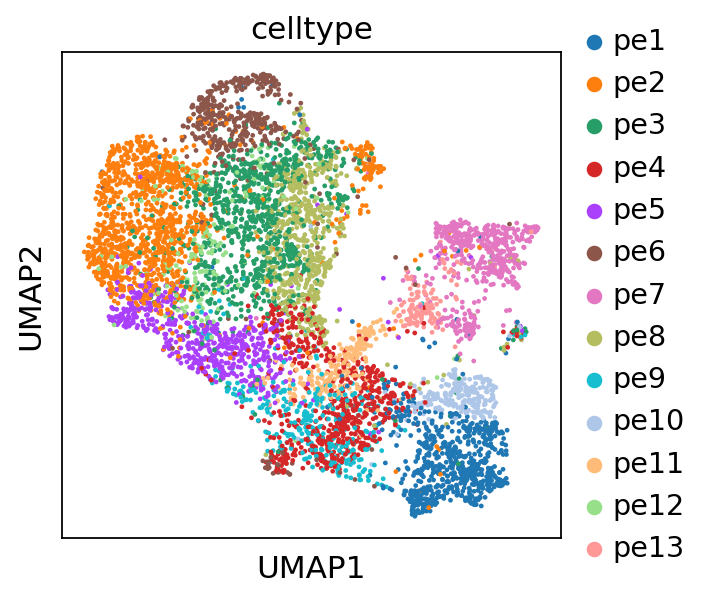

In [14]:
sc.pp.neighbors(rna_E12_1, metric="cosine")
sc.tl.umap(rna_E12_1)
sc.pl.umap(rna_E12_1, color="celltype")

In [15]:
rna_E12_1.write_h5ad("../process/framework/obj/rna_E12.5_1_scglue_prepare.h5ad")

In [22]:
atac = sc.read_h5ad("../process/framework/obj/combined_E12_E14_signc_sceasy.h5ad")

In [27]:
atac.obs["batch"].value_counts()

batch
B1    14738
C2    10346
B2    10309
C1     6649
Name: count, dtype: int64

In [30]:
split = atac.var_names.str.split(r"[:-]")
atac.var["chrom"] = split.map(lambda x: x[0])
atac.var["chromStart"] = split.map(lambda x: x[1]).astype(int)
atac.var["chromEnd"] = split.map(lambda x: x[2]).astype(int)
atac.var.head()

,name,chrom,chromStart,chromEnd
chr1-3046200-3047106,chr1-3046200-3047106,chr1,3046200,3047106
chr1-3094219-3095343,chr1-3094219-3095343,chr1,3094219,3095343
chr1-3165484-3166526,chr1-3165484-3166526,chr1,3165484,3166526
chr1-3184626-3185668,chr1-3184626-3185668,chr1,3184626,3185668
chr1-3185936-3186838,chr1-3185936-3186838,chr1,3185936,3186838


In [31]:
scglue.data.lsi(atacC12_1, n_components=100, n_iter=15)
sc.pp.neighbors(atacC12_1, use_rep="X_lsi", metric="cosine")
sc.tl.umap(atacC12_1)

/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/scglue/num.py:289: RuntimeWarning: divide by zero encountered in divide
  idf = X.shape[0] / X.sum(axis=0)
/home/zhanglab/mambaforge/envs/py311/lib/python3.11/site-packages/scglue/data.py:82: ImplicitModificationWarning: Setting element `.obsm['X_lsi']` of view, initializing view as actual.
  adata.obsm["X_lsi"] = X_lsi


In [39]:
atacC12_1.X[1:10,1:10].toarray()

array([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0.]])

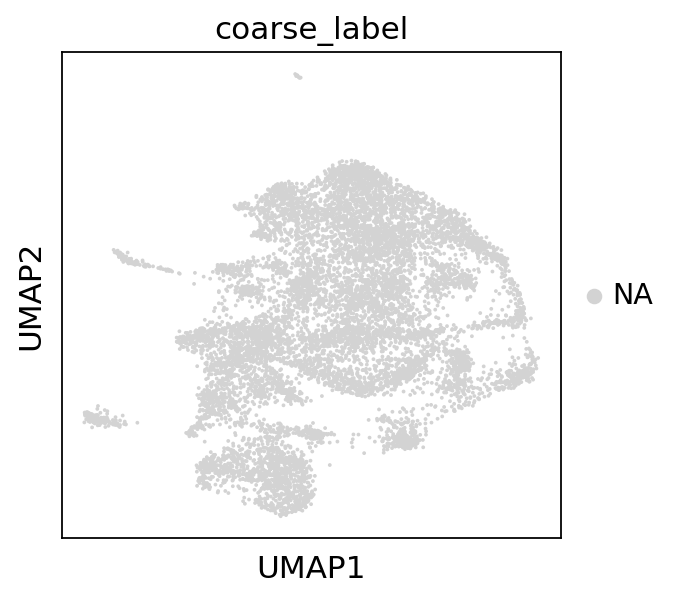

In [35]:
sc.pl.umap(atacC12_1, color="coarse_label")

In [28]:
atacC12_1 = atac[atac.obs["batch"] == "C2"]

In [41]:
atacC12_1.write_h5ad("../process/framework/obj/atac_E12.5_1_scglue_prepare.h5ad")

In [43]:
split = atacC12_1.var_names.str.split(r"[:-]")
atacC12_1.var["chrom"] = split.map(lambda x: x[0])
atacC12_1.var["chromStart"] = split.map(lambda x: x[1]).astype(int)
atacC12_1.var["chromEnd"] = split.map(lambda x: x[2]).astype(int)
atacC12_1.var.head()

,name,chrom,chromStart,chromEnd
chr1-3046200-3047106,chr1-3046200-3047106,chr1,3046200,3047106
chr1-3094219-3095343,chr1-3094219-3095343,chr1,3094219,3095343
chr1-3165484-3166526,chr1-3165484-3166526,chr1,3165484,3166526
chr1-3184626-3185668,chr1-3184626-3185668,chr1,3184626,3185668
chr1-3185936-3186838,chr1-3185936-3186838,chr1,3185936,3186838


In [45]:
scglue.data.get_gene_annotation(
    rna_E12_1, gtf="../../../database/gtf/gencode.vM25.chr_patch_hapl_scaff.annotation.gtf.gz",
    gtf_by="gene_name"
)

In [51]:
rna_E12_1.var.assign(name=rna_E12_1.var_names)

,highly_variable,highly_variable_rank,means,variances,variances_norm,mean,std,chrom,chromStart,chromEnd,...,thickEnd,itemRgb,blockCount,blockSizes,blockStarts,gene_id,gene_type,mgi_id,havana_gene,tag
Xkr4,True,460.0,0.224668,0.735821,2.506224,0.102858,0.311695,chr1,3205900.0,3671498.0,...,.,.,.,.,.,ENSMUSG00000051951.5,protein_coding,MGI:3528744,OTTMUSG00000026353.2,NaN
Gm1992,False,NaN,0.003821,0.004418,0.960192,0.002154,0.037733,chr1,3466586.0,3513553.0,...,.,.,.,.,.,ENSMUSG00000089699.1,antisense,MGI:3780162,OTTMUSG00000026352.1,NaN
Rp1,False,NaN,0.000459,0.000458,0.968790,0.000152,0.007123,chr1,3999556.0,4409241.0,...,.,.,.,.,.,ENSMUSG00000025900.13,protein_coding,MGI:1341105,OTTMUSG00000049985.3,overlapping_locus
Sox17,False,NaN,0.000459,0.000458,0.968790,0.000281,0.014427,chr1,4490930.0,4497354.0,...,.,.,.,.,.,ENSMUSG00000025902.13,protein_coding,MGI:107543,OTTMUSG00000050014.7,NaN
Mrpl15,False,NaN,2.002445,3.138484,0.786151,0.873334,0.544115,chr1,4773205.0,4785739.0,...,.,.,.,.,.,ENSMUSG00000033845.13,protein_coding,MGI:1351639,OTTMUSG00000029329.3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Olfr1501,False,NaN,0.000000,0.000000,0.000000,0.000000,1.000000,chr19,13835032.0,13850692.0,...,.,.,.,.,.,ENSMUSG00000057270.3,protein_coding,MGI:3031335,OTTMUSG00000059638.2,NaN
4933411K16Rik,False,NaN,0.000000,0.000000,0.000000,0.000000,1.000000,chr19,42052247.0,42053627.0,...,.,.,.,.,.,ENSMUSG00000090369.3,protein_coding,MGI:1914015,OTTMUSG00000035807.1,overlapping_locus
Gm10197,False,NaN,0.000000,0.000000,0.000000,0.000000,1.000000,chr19,53371565.0,53371766.0,...,.,.,.,.,.,ENSMUSG00000067085.1,protein_coding,MGI:3704501,NaN,NaN
Gm26874,False,NaN,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
varIndex = rna_E12_1.var.loc[:, ["chrom", "chromStart", "chromEnd"]].dropna().index

In [58]:
rna_E12_1 = rna_E12_1[:,varIndex]

In [59]:
guidance = scglue.genomics.rna_anchored_guidance_graph(rna_E12_1, atacC12_1)
guidance

window_graph:   0%|          | 0/21638 [00:00<?, ?it/s]

In [60]:
scglue.graph.check_graph(guidance, [rna_E12_1, atacC12_1])

[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] check_graph: All checks passed!


In [62]:
!mkdir -p ../process/scglue/E12

In [63]:
nx.write_graphml(guidance, "../process/guidance.graphml.gz")

In [ ]:
sc.pp.normalize_total(rna_raw)
sc.pp.log1p(rna_raw)
sc.pp.scale(rna_raw)
sc.tl.pca(rna_raw, n_comps=100, svd_solver="auto")

In [ ]:
scglue.data.lsi(atac, n_components=100, n_iter=15)
sc.pp.neighbors(atac, use_rep="X_lsi", metric="cosine")
sc.tl.umap(atac)

In [71]:
atac.write_h5ad("../process/framework/obj/atac_scglue_prepare.h5ad")

In [72]:
rna_raw = rna_raw[:,varIndex]

In [73]:
rna_raw

View of AnnData object with n_obs × n_vars = 19404 × 21638
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'group', 'SCT_snn_res.0.6', 'celltype', 'SCT_snn_res.0.4', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'ident'
    var: 'mean', 'std'
    uns: 'X_name', 'log1p', 'pca'
    obsm: 'HARMONY', 'PCA', 'UMAP', 'X_pca'
    varm: 'PCs'
    layers: 'logcounts', 'counts'

In [74]:
rna_raw.write_h5ad("../process/framework/obj/rna_raw_scglue_prepare.h5ad")